# Effectiveness of thrombolysis in early (4hr) arrivals of mild stroke - discharge mRS 0-2: Causal Forest

## Selection criteria

* Arrival within 4 hours of known stroke onset time
* No thrombectomy
* Stroke type = infarction
* No recorded use of perfusion imaging
* Stroke severity 1-5

## Outcome of interest

* Discharge mRS 0-2.

## Key features of interest

* Onset to thrombolysis time

## Adjustment features used:

* Prior disability
* Stroke severity
* Age
* Congestive heart failure
* Hypertension
* Diabetes
* Atrial fibrillation anticoagulant
* Any atrial fibrillation diagnosis (existing or new)
* Stroke team
* Ethnicity

To estimate how the effect of thrombolysis varied between patients, we used a causal forest estimated within a double machine learning framework (CausalForestDML, EconML). In clinical terms, the method asks: for patients who look alike, did those who received thrombolysis do better than we would have expected them to? It works in two stages.

In the first stage, two prediction models were built with gradient-boosted decision trees (LightGBM). The first predicted each patient's probability of discharge with mRS 0–2 from their baseline characteristics and stroke team, without knowing the treatment given. These characteristics were age, stroke severity, pre-stroke disability, comorbidities, atrial fibrillation and anticoagulation status, and ethnicity. The second predicted the probability of each treatment category from the same information: no thrombolysis, or thrombolysis within <180, 180–270 or 270–360 minutes of onset. It therefore captures the clinical and organisational factors that influence who is treated.

The models used five-fold cross-fitting, so each patient's predictions came from models trained on other patients. Subtracting the predictions from what actually happened left two residuals: how much better or worse each patient's outcome was than expected, and how far their treatment differed from what would typically be given to someone like them. Removing the predictable part of both treatment and outcome adjusts for measured confounding, including confounding by indication. A further advantage is that small errors in either prediction model have only a limited, second-order effect on the final estimates.

In the second stage, a forest of 2,000 "honest" trees related the outcome residuals to the treatment residuals. Each tree used one half of its data to choose how to split patients into subgroups and the other half to estimate the treatment effect within them, which reduces overfitting. The result was an estimated absolute change in the probability of mRS 0–2 for each patient under each treatment window compared with no thrombolysis. These estimates were then summarised by treatment window and by patient characteristics.

As with any observational analysis, the estimates assume there is no important unmeasured confounding, and that comparable patients were found in both the treated and untreated groups.

![](./images/dml_causal_forest_thrombolysis_method.png)

## Load modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import statsmodels.api as sm

from econml.dml import CausalForestDML # Causal forest with double machine learning
from lightgbm import LGBMClassifier, LGBMRegressor


# Disable warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

## Define mRS outcome target

In [2]:
MRS_TARGET = 2 # Model will set y as being less than or equal to this value

## Load and filter data

In [3]:
data = pd.read_csv("../../data/sam3/cleaned_data_anon_teams.csv", low_memory=False)

print(f"Initial data shape: {data.shape}")

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only infarction cases
data = data[data["infarction"] == 1]

# Keep only onset to arrival < 240 mins
data = data[data["onset_to_arrival_time"] < 240]

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only perfusion_imaging_used == 0
data = data[data["perfusion_imaging_used"] == 0]

# Exlude patients who received thrombectomy
data = data[data["thrombectomy"] == 0]

# Limit to stroke severity  1 - 5 
data = data[(data["stroke_severity"] >= 1) & (data["stroke_severity"] <= 5)]

# Keep only teams with at least 10 onset_to_thrombolysis_time
team_counts = data.groupby("stroke_team")["onset_to_thrombolysis_time"].count()
valid_teams = team_counts[team_counts >= 10].index
data = data[data["stroke_team"].isin(valid_teams)]

# Missing treatment times -> sentinel
data["onset_to_thrombolysis_time"] = data["onset_to_thrombolysis_time"].fillna(99999)

# Exclude late thrombolysis (> 360) unless sentinel
data = data[
    (data["onset_to_thrombolysis_time"] <= 360)
    | (data["onset_to_thrombolysis_time"] == 99999)
]

# Add mrs less than threshold
data['outcome_target'] = (data['discharge_disability'] <= MRS_TARGET).astype(int)

print(f"Final data shape: {data.shape}")

# Treatment counts
num_thrombolysis = (data["onset_to_thrombolysis_time"] != 99999).sum()
print(f"Number of patients with thrombolysis: {num_thrombolysis}")

# Create age groups of 10 years
data["age_group"] = pd.cut(data["age"], bins=np.arange(0, 110, 10), right=False)

Initial data shape: (452863, 72)
Final data shape: (58389, 73)
Number of patients with thrombolysis: 13380


Add time labels, and patient ID.

In [4]:
data.loc[data["onset_to_thrombolysis_time"] <= 180, "treatment_group"] = "<180 min"
data.loc[(data["onset_to_thrombolysis_time"] > 180) & (data["onset_to_thrombolysis_time"] <= 270), "treatment_group"] = "180-270 min"
data.loc[(data["onset_to_thrombolysis_time"] > 270) & (data["onset_to_thrombolysis_time"] <= 360), "treatment_group"] = "270-360 min"
data.loc[data["onset_to_thrombolysis_time"] == 99999, "treatment_group"] = "No thrombolysis"

# Add patient ID for honest splitting in Causal Forest

data["patient_id"] = np.arange(len(data))


## Define adjustment fields

In [5]:
# Descriptive features (not used in model building)

NON_CATEGORICAL_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
]

CATEGORICAL_FEATURES = [
    'age_group',
    'stroke_team',
    'ethnicity',
    'treatment_group'
]

descriptive_features = list(set(NON_CATEGORICAL_FEATURES + CATEGORICAL_FEATURES))

"""
X is the set of variables you want the treatment effect to depend on. # The causal forest builds 
trees that split on X, grouping patients so that the treatment effect is roughly constant within
a leaf.

W is the set of variables you want to control for. The causal forest will adjust for these 
variables, but will not split on them.

A feature belongs in X if you think the treatment effect may vary with it, and in W if it's a
confounder you need to adjust away. Many variables are both a confounder and an effect modifier, 
so they legitimately belong in both groups.
"""


X_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'ethnicity',
]

W_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'ethnicity',
    'stroke_team',
]

TREATMENTS = [
    'onset_to_thrombolysis_time',
]

# Combine the X and W treatment features into a single list of features
cf_features = list(set(X_FEATURES + W_FEATURES + TREATMENTS))


## Descriptive statistics

In [6]:
# Produce descriptive stats by treatment type
descriptive_data = data[descriptive_features].copy(deep=True)
descriptive_stats = descriptive_data.groupby('treatment_group').describe()
descriptive_stats.T

treatment_group                 180-270 min  270-360 min     <180 min  \
diabetes                 count  5514.000000   476.000000  7390.000000   
                         mean      0.203663     0.186975     0.179567   
                         std       0.402758     0.390301     0.383852   
                         min       0.000000     0.000000     0.000000   
                         25%       0.000000     0.000000     0.000000   
                         50%       0.000000     0.000000     0.000000   
                         75%       0.000000     0.000000     0.000000   
                         max       1.000000     1.000000     1.000000   
hypertension             count  5514.000000   476.000000  7390.000000   
                         mean      0.531012     0.508403     0.498647   
                         std       0.499083     0.500455     0.500032   
                         min       0.000000     0.000000     0.000000   
                         25%       0.000000     0.000000     0.000000   
                         50%       1.000000     1.000000     0.000000   
                         75%       1.000000     1.000000     1.000000   
                         max       1.000000     1.000000     1.000000   
stroke_severity          count  5514.000000   476.000000  7390.000000   
                         mean      3.642546     3.460084     3.723545   
                         std       1.214554     1.255088     1.172392   
                         min       1.000000     1.000000     1.000000   
                         25%       3.000000     2.000000     3.000000   
                         50%       4.000000     4.000000     4.000000   
                         75%       5.000000     5.000000     5.000000   
                         max       5.000000     5.000000     5.000000   
prior_disability         count  5514.000000   476.000000  7390.000000   
                         mean      0.567646     0.468487     0.489986   
                         std       0.966261     0.839207     0.910887   
                         min       0.000000     0.000000     0.000000   
                         25%       0.000000     0.000000     0.000000   
                         50%       0.000000     0.000000     0.000000   
                         75%       1.000000     1.000000     1.000000   
                         max       5.000000     4.000000     5.000000   
any_afib_diagnosis       count  5514.000000   476.000000  7390.000000   
                         mean      0.121146     0.128151     0.123275   
                         std       0.326327     0.334610     0.328775   
                         min       0.000000     0.000000     0.000000   
                         25%       0.000000     0.000000     0.000000   
                         50%       0.000000     0.000000     0.000000   
                         75%       0.000000     0.000000     0.000000   
                         max       1.000000     1.000000     1.000000   
congestive_heart_failure count  5514.000000   476.000000  7390.000000   
                         mean      0.036090     0.021008     0.035047   
                         std       0.186531     0.143563     0.183912   
                         min       0.000000     0.000000     0.000000   
                         25%       0.000000     0.000000     0.000000   
                         50%       0.000000     0.000000     0.000000   
                         75%       0.000000     0.000000     0.000000   
                         max       1.000000     1.000000     1.000000   
afib_anticoagulant       count  5514.000000   476.000000  7390.000000   
                         mean      0.023395     0.033613     0.021245   
                         std       0.151168     0.180422     0.144210   
                         min       0.000000     0.000000     0.000000   
                         25%       0.000000     0.000000     0.000000   
                         50%       0.000000     0.000000  

In [7]:
ordered_arms = [
    "No thrombolysis",
    "<180 min",
    "180-270 min",
    "270-360 min"
]

# Format the descriptive stats so it shows mean ± sd and n in brackets.
# Have features as rows and treatment groups as columns.
feature_order = [
    feature
    for feature in pd.Index(descriptive_stats.columns.get_level_values(0)).unique()
    if feature != "treatment_type"
]

formatted_descriptive_stats = pd.DataFrame(index=feature_order)

for group in ordered_arms:
    if group in descriptive_stats.index:
        group_stats = descriptive_stats.loc[group]
        formatted_descriptive_stats[group] = [
            f"{group_stats[(feature, 'mean')]:.2f} ± {group_stats[(feature, 'std')]:.2f} "
            f"(n={int(group_stats[(feature, 'count')])})"
            for feature in feature_order
    ]

formatted_descriptive_stats.index.name = "feature"

# Replace _ with space in the index and column names
formatted_descriptive_stats.index = formatted_descriptive_stats.index.str.replace("_", " ")
formatted_descriptive_stats.columns = formatted_descriptive_stats.columns.str.replace("_", " ")
formatted_descriptive_stats

,No thrombolysis,<180 min,180-270 min,270-360 min
feature,,,,
diabetes,0.23 ± 0.42 (n=45009),0.18 ± 0.38 (n=7390),0.20 ± 0.40 (n=5514),0.19 ± 0.39 (n=476)
hypertension,0.57 ± 0.50 (n=45009),0.50 ± 0.50 (n=7390),0.53 ± 0.50 (n=5514),0.51 ± 0.50 (n=476)
stroke severity,2.66 ± 1.30 (n=45009),3.72 ± 1.17 (n=7390),3.64 ± 1.21 (n=5514),3.46 ± 1.26 (n=476)
prior disability,0.97 ± 1.25 (n=45009),0.49 ± 0.91 (n=7390),0.57 ± 0.97 (n=5514),0.47 ± 0.84 (n=476)
any afib diagnosis,0.25 ± 0.43 (n=45009),0.12 ± 0.33 (n=7390),0.12 ± 0.33 (n=5514),0.13 ± 0.33 (n=476)
congestive heart failure,0.06 ± 0.23 (n=45009),0.04 ± 0.18 (n=7390),0.04 ± 0.19 (n=5514),0.02 ± 0.14 (n=476)
afib anticoagulant,0.19 ± 0.39 (n=45009),0.02 ± 0.14 (n=7390),0.02 ± 0.15 (n=5514),0.03 ± 0.18 (n=476)


In [8]:
# Summary mean, sd, and time time to thrombolysis and thrombectomy by treatment type
summary_times = data.groupby("treatment_group")[['onset_to_thrombolysis_time']].agg(["mean", "std", "count"])
summary_times = summary_times.reindex(ordered_arms)
summary_times.round(1)

onset_to_thrombolysis_time             
                                      mean   std  count
treatment_group                                        
No thrombolysis                    99999.0   0.0  45009
<180 min                             136.7  28.8   7390
180-270 min                          221.7  25.7   5514
270-360 min                          294.0  22.2    476

## Define model

In [9]:
# ---------------------------------------------------------------------------
# Picklable LightGBM wrappers with NATIVE categorical handling.
# LightGBM (>=4.x) IGNORES `categorical_feature` on the constructor, so we
# inject it into `.fit()`. These are defined at MODULE LEVEL (not inside a
# function) so fitted EconML estimators containing them remain picklable and
# `sklearn.clone`-compatible. `cat_features` is a real constructor param, so
# get_params/set_params round-trips it (required by clone / EconML).
# ---------------------------------------------------------------------------
class CatLGBMClassifier(LGBMClassifier):
    def __init__(self, cat_features="auto", **kwargs):
        self.cat_features = cat_features
        super().__init__(**kwargs)

    def get_params(self, deep=True):
        params = super().get_params(deep=deep)
        params["cat_features"] = self.cat_features
        return params

    def fit(self, X, y, **kw):
        kw.setdefault("categorical_feature", self.cat_features)
        return super().fit(X, y, **kw)


class CatLGBMRegressor(LGBMRegressor):
    def __init__(self, cat_features="auto", **kwargs):
        self.cat_features = cat_features
        super().__init__(**kwargs)

    def get_params(self, deep=True):
        params = super().get_params(deep=deep)
        params["cat_features"] = self.cat_features
        return params

    def fit(self, X, y, **kw):
        kw.setdefault("categorical_feature", self.cat_features)
        return super().fit(X, y, **kw)

In [10]:
# EconML one-hot encodes a discrete treatment internally; the alphabetically
# first level is the baseline. We force "No thrombolysis" to sort first.
arm = data["treatment_group"].map(
    {
    "No thrombolysis": "0_No_thrombolysis",
    "<180 min": "1_<180_min",
    "180-270 min": "2_180-270_min",
    "270-360 min": "3_270-360_min"
    }
).to_numpy()

In [11]:
# ---------------------------------------------------------------------
# Categorical encoding helper for NATIVE LightGBM categorical handling
# ---------------------------------------------------------------------
def encode_categoricals_as_codes(frame, cat_cols):
    """
    Turn nominal categorical columns into NON-NEGATIVE integer codes suitable
    for LightGBM's native categorical handling (passed via `categorical_feature`
    as column indices). Unknown/missing map to a dedicated highest code rather
    than -1 (LightGBM requires non-negative category ids). Returns an (n, k)
    int array with one column per cat_col, in the given order.
    """
    codes = []
    for col in cat_cols:
        ser = frame[col].astype(str).replace({"nan": "Empty", "": "Empty"}).fillna("Empty")
        cat = ser.astype("category").cat.codes.to_numpy()   # 0..K-1, no -1 here
        codes.append(cat.astype(np.int64))
    return np.column_stack(codes) if codes else np.empty((len(frame), 0))

In [12]:
# ---------------------------------------------------------------------------
# Feature matrices
# ---------------------------------------------------------------------------
def build_matrices(data):
    """
    Returns:
      X  : heterogeneity features (pre-treatment clinical only) for CATE splits
      W  : nuisance controls (X + integer-coded categoricals) for residualising
      cat_idx : column indices in W that are categorical (for LightGBM)
      y  : binary good-outcome target
      groups : stroke_team codes for cluster-robust cross-fitting
    """
    y = (data["discharge_disability"] <= MRS_TARGET).astype(int).to_numpy()

    cat_encoded = encode_categoricals_as_codes(data, CATEGORICAL_FEATURES)

    X = data[X_FEATURES].copy()
    for col in CATEGORICAL_FEATURES:
        if col in X.columns:
            X[col] = cat_encoded[:, CATEGORICAL_FEATURES.index(col)]
    # Get the column indices of the categorical features in X
    cat_idx_x = [X.columns.get_loc(col) for col in CATEGORICAL_FEATURES if col in X.columns]

    W = data[W_FEATURES].copy()
    for col in CATEGORICAL_FEATURES:
        if col in W.columns:
            W[col] = cat_encoded[:, CATEGORICAL_FEATURES.index(col)]
    cat_idx_w = [W.columns.get_loc(col) for col in CATEGORICAL_FEATURES if col in W.columns]

    groups = data["patient_id"].to_numpy()

    return X, W, y, groups, cat_idx_x, cat_idx_w

In [13]:
X, W, y, groups, cat_idx_x, cat_idx_w = build_matrices(data)

In [14]:
def make_nuisances(discrete_treatment, cat_features_x=None, cat_features_w=None):
    """LightGBM nuisance learners with NATIVE categorical handling.
    """
    cat_idx_x = cat_features_x if cat_features_x is not None else "auto"
    cat_idx_w = cat_features_w if cat_features_w is not None else "auto"
    common = dict(
        n_estimators=400, num_leaves=31, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=-1, verbosity=-1,
    )
    model_y = CatLGBMClassifier(cat_features=cat_idx_x, **common)
    if discrete_treatment:
        model_t = CatLGBMClassifier(cat_features=cat_idx_w, **common)
    else:
        model_t = CatLGBMRegressor(cat_features=cat_idx_w, **common)
        
    return model_y, model_t

In [15]:
model_y, model_t = make_nuisances(
    discrete_treatment=True,
    cat_features_x=cat_idx_x,
    cat_features_w=cat_idx_w)

In [16]:
est = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_treatment=True,
    discrete_outcome=True,
    n_estimators=2000,
    min_samples_leaf=25,
    max_depth=None,
    honest=True,
    cv=5,
    verbose=False,
    random_state=42,
    n_jobs=-1,
)

est.fit(y, arm, X=X, W=W, groups=groups)

In [17]:
baseline = "0_No_thrombolysis"
other_arms = ["1_<180_min", "2_180-270_min", "3_270-360_min"]

cate_results = {}

for a in other_arms:
    cate = est.effect(X.to_numpy(), T0=baseline, T1=a)
    cate_results[a] = cate
    print(f"Estimated CATE for {a}, shape: {cate.shape}")


Estimated CATE for 1_<180_min, shape: (58389, 1)
Estimated CATE for 2_180-270_min, shape: (58389, 1)
Estimated CATE for 3_270-360_min, shape: (58389, 1)


In [18]:
# Copy X to a new dataframe
cate_df = X.copy()
cate_df[f"mrs_0-{MRS_TARGET}"] = y
cate_df["treatment_group"] = data["treatment_group"]
cate_df["cate"] = 0.0  # one scalar CATE column

# Fill CATE by observed treatment arm
for a in other_arms:
    arm_label = a.split("_", 1)[1].replace("_", " ")
    mask = cate_df["treatment_group"] == arm_label
    cate_df.loc[mask, "cate"] = cate_results[a].ravel()[mask.to_numpy()]

cate_df.to_csv(f"./output/causal_forest_cate_estimates_{MRS_TARGET}.csv", index=True)


# Replace ethnicity code with the original ethnicity and age column from the data
cate_df['ethnicity'] = data['ethnicity']
cate_df['age_group'] = data['age_group']

cate_df

,prior_disability,stroke_severity,age,congestive_heart_failure,hypertension,diabetes,afib_anticoagulant,any_afib_diagnosis,ethnicity,mrs_0-2,treatment_group,cate,age_group
6,2,1.0,92.5,0.0,1.0,0.0,0.0,0.0,White,1,No thrombolysis,0.0,"[90, 100)"
9,3,4.0,77.5,0.0,0.0,0.0,0.0,0.0,White,0,No thrombolysis,0.0,"[70, 80)"
10,1,3.0,62.5,0.0,1.0,0.0,0.0,0.0,Asian,1,No thrombolysis,0.0,"[60, 70)"
19,0,2.0,42.5,0.0,0.0,0.0,0.0,0.0,White,1,No thrombolysis,0.0,"[40, 50)"
27,3,5.0,87.5,0.0,1.0,0.0,0.0,0.0,White,0,No thrombolysis,0.0,"[80, 90)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
452800,2,2.0,82.5,0.0,1.0,0.0,1.0,1.0,White,1,No thrombolysis,0.0,"[80, 90)"
452804,0,3.0,82.5,0.0,1.0,0.0,1.0,1.0,White,1,No thrombolysis,0.0,"[80, 90)"
452805,0,2.0,72.5,0.0,1.0,1.0,0.0,0.0,White,1,No thrombolysis,0.0,"[70, 80)"
452810,0,3.0,67.5,0.0,0.0,0.0,0.0,0.0,Other/NK,0,No thrombolysis,0.0,"[60, 70)"


In [19]:
# Calculate mean, SD, and 95% CI of CATE for each treatment arm
cate_summary = cate_df.groupby("treatment_group")["cate"].agg(["mean", "std", "count"])
cate_summary["95% CI lower"] = cate_summary["mean"] - 1.96 * cate_summary["std"] / np.sqrt(cate_summary["count"])
cate_summary["95% CI upper"] = cate_summary["mean"] + 1.96 * cate_summary["std"] / np.sqrt(cate_summary["count"])

ordered_arms = [
    "<180 min",
    "180-270 min",
    "270-360 min"
]
cate_summary = cate_summary.reindex(ordered_arms).round(4)

cate_summary

,mean,std,count,95% CI lower,95% CI upper
treatment_group,,,,,
<180 min,0.0655,0.0638,7390,0.0641,0.0670
180-270 min,0.0376,0.0722,5514,0.0357,0.0395
270-360 min,0.0302,0.2030,476,0.0120,0.0485


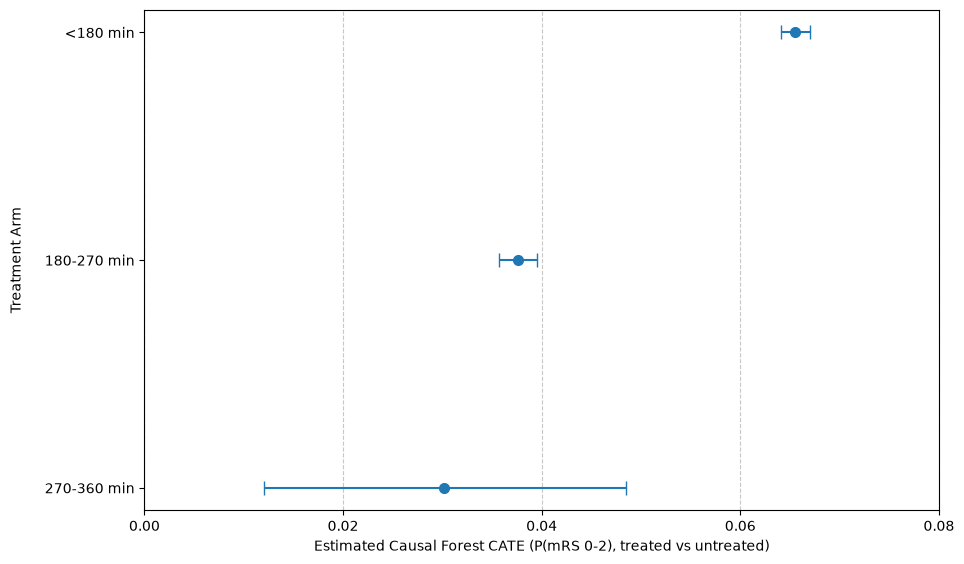

In [20]:
# Add n values to the y tick labels
n_values = cate_summary["count"].astype(int).to_dict()

fig, ax = plt.subplots(figsize=(10, 6))
# Plot the mean CATE with error bars for 95% CI
ax.errorbar(
    y=range(len(cate_summary.index) - 1, -1, -1),
    x=cate_summary["mean"],
    xerr=[
        cate_summary["mean"] - cate_summary["95% CI lower"],
        cate_summary["95% CI upper"] - cate_summary["mean"],
    ],
    fmt="o",
    markersize=7,  # increase point size
    capsize=5,
    label="Estimated CATE with 95% CI",
)
# Make x min =0
ax.set_xlim(left=0)
# x_tick at 0.02 intervals
xmin, xmax = ax.get_xlim()
ax.set_xticks(
    np.arange(
        np.floor(xmin / 0.02) * 0.02,
        np.ceil(xmax / 0.02) * 0.02 + 0.02,
        0.02
    )
)
# Add y tick labels for treatment arms
ax.set_yticks(range(len(cate_summary.index) - 1, -1, -1))
# For y tick labels replace _ with space
ax.set_yticklabels(cate_summary.index)
# Label the axes
ax.set_xlabel(f"Estimated Causal Forest CATE (P(mRS 0-{MRS_TARGET}), treated vs untreated)")
ax.set_ylabel(f"Treatment Arm", labelpad=15)
# Add grid lines
ax.grid(axis="x", linestyle="--", alpha=0.7)
# Add a horizontal line at y=0
ax.axvline(x=0, linestyle="--", alpha=0.7)
plt.tight_layout(pad=2)
plt.savefig(f"./output/causal_forest_counterfactual_cate_estimates_{MRS_TARGET}.png", dpi=300)
plt.show()

In [21]:
# For each treatment group calculate the mean, SD, and 95% CI of CATE by stroke severity.
# Put in a dataframe with columns: treatment_group, stroke_severity, mean_cate, std_cate, count_cate, ci_lower, ci_upper

groups_to_plot = ["<180 min", "180-270 min"]

cate_by_severity = []
for group_to_plot in groups_to_plot:
    group_data = cate_df[cate_df['treatment_group'] == group_to_plot]
    for severity in sorted(group_data['stroke_severity'].unique()):
        severity_data = group_data[group_data['stroke_severity'] == severity]
        mean_cate = severity_data['cate'].mean()
        std_cate = severity_data['cate'].std()
        count_cate = severity_data['cate'].count()
        ci_lower = mean_cate - 1.96 * std_cate / np.sqrt(count_cate)
        ci_upper = mean_cate + 1.96 * std_cate / np.sqrt(count_cate)
        
        cate_by_severity.append({
            'treatment_group': group_to_plot,
            'stroke_severity': severity,
            'mean_cate': mean_cate,
            'std_cate': std_cate,
            'count_cate': count_cate,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        })
cate_by_severity_df = pd.DataFrame(cate_by_severity)

# Add untreeated proportion of mRS 0-2 by stroke severity
untreated_data = cate_df[cate_df['treatment_group'] == "No thrombolysis"]
untreated_proportions = untreated_data.groupby('stroke_severity')[f'mrs_0-{MRS_TARGET}'].mean().reset_index()
untreated_proportions.rename(columns={f'mrs_0-{MRS_TARGET}': 'untreated_proportion'}, inplace=True)
cate_by_severity_df = cate_by_severity_df.merge(untreated_proportions, on='stroke_severity', how='left')

cate_by_severity_df = cate_by_severity_df.round(3)
cate_by_severity_df.to_csv(f"./output/cate_by_severity_{MRS_TARGET}.csv", index=False)
cate_by_severity_df


,treatment_group,stroke_severity,mean_cate,std_cate,count_cate,ci_lower,ci_upper,untreated_proportion
0,<180 min,1.0,-0.013,0.073,347,-0.021,-0.005,0.775
1,<180 min,2.0,0.008,0.067,925,0.003,0.012,0.702
2,<180 min,3.0,0.053,0.054,1525,0.050,0.056,0.613
3,<180 min,4.0,0.077,0.056,2220,0.075,0.079,0.529
4,<180 min,5.0,0.097,0.044,2373,0.095,0.099,0.469
5,180-270 min,1.0,-0.012,0.081,341,-0.020,-0.003,0.775
6,180-270 min,2.0,0.007,0.079,732,0.002,0.013,0.702
7,180-270 min,3.0,0.049,0.071,1162,0.045,0.053,0.613
8,180-270 min,4.0,0.042,0.052,1601,0.040,0.045,0.529
9,180-270 min,5.0,0.048,0.077,1678,0.045,0.052,0.469


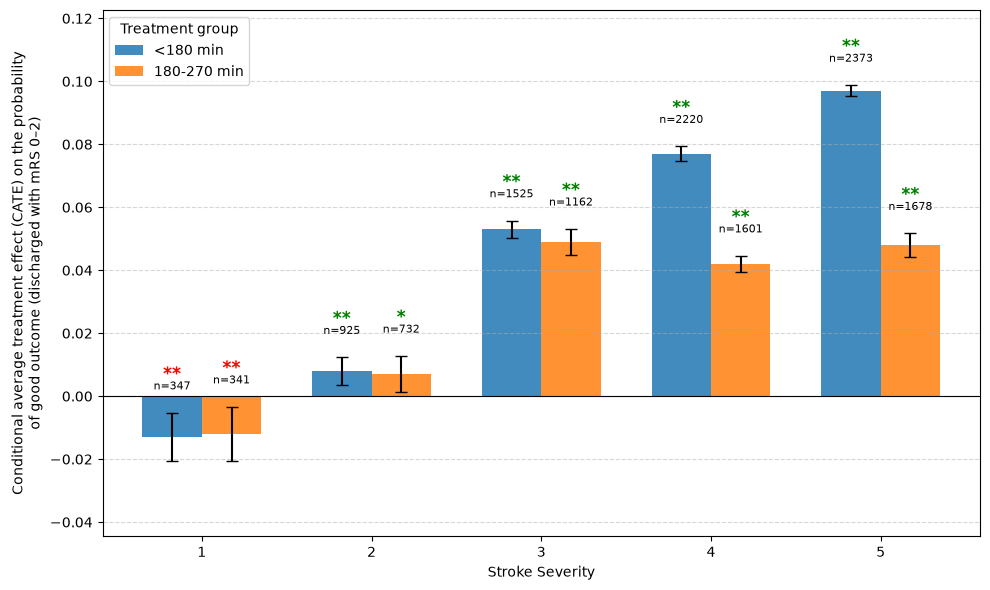

In [22]:
# Vertical bars with asymmetric 95% confidence intervals, counts, and significance markers
groups = ["<180 min", "180-270 min"]
severities = sorted(cate_by_severity_df["stroke_severity"].unique())

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(severities))
bar_width = 0.35

for i, group in enumerate(groups):
    group_data = (
        cate_by_severity_df[
            cate_by_severity_df["treatment_group"] == group
        ]
        .set_index("stroke_severity")
        .reindex(severities)
    )

    y = group_data["mean_cate"].to_numpy()
    count = group_data["count_cate"].to_numpy()
    se = group_data["std_cate"].to_numpy() / np.sqrt(count)

    ci_lower_95 = y - 1.96 * se
    ci_upper_95 = y + 1.96 * se
    ci_lower_99 = y - 2.576 * se
    ci_upper_99 = y + 2.576 * se

    yerr = np.vstack([y - ci_lower_95, ci_upper_95 - y])
    bar_positions = x + (i - 0.5) * bar_width

    ax.bar(
        bar_positions,
        y,
        width=bar_width,
        yerr=yerr,
        capsize=4,
        label=group,
        alpha=0.85,
    )

    for bar_x, n, upper_95, lower_95, lower_99, upper_99 in zip(
        bar_positions, count, ci_upper_95, ci_lower_95, ci_lower_99, ci_upper_99
    ):
        # Add sample count above each error bar
        ax.annotate(
            f"n={int(n)}",
            xy=(bar_x, upper_95),
            xytext=(0, 15),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )

        if lower_99 > 0:
            stars = "**"
            colour = "green"
        elif lower_95 > 0:
            stars = "*"
            colour = "green"
        elif upper_99 < 0:
            stars = "**"
            colour = "red"
        elif upper_95 < 0:
            stars = "*"
            colour = "red"
        else:
            continue

        ax.annotate(
            stars,
            xy=(bar_x, upper_95),
            xytext=(0, 22),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            color=colour,
        )

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{int(severity)}" for severity in severities])
ax.set_xlabel("Stroke Severity")
ax.set_ylabel(
    f"Conditional average treatment effect (CATE) on the probability\n"
    f"of good outcome (discharged with mRS 0–{MRS_TARGET})"
)
ax.legend(title="Treatment group")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.margins(y=0.2)

plt.tight_layout()
plt.savefig(
    f"./output/cate_by_severity_{MRS_TARGET}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

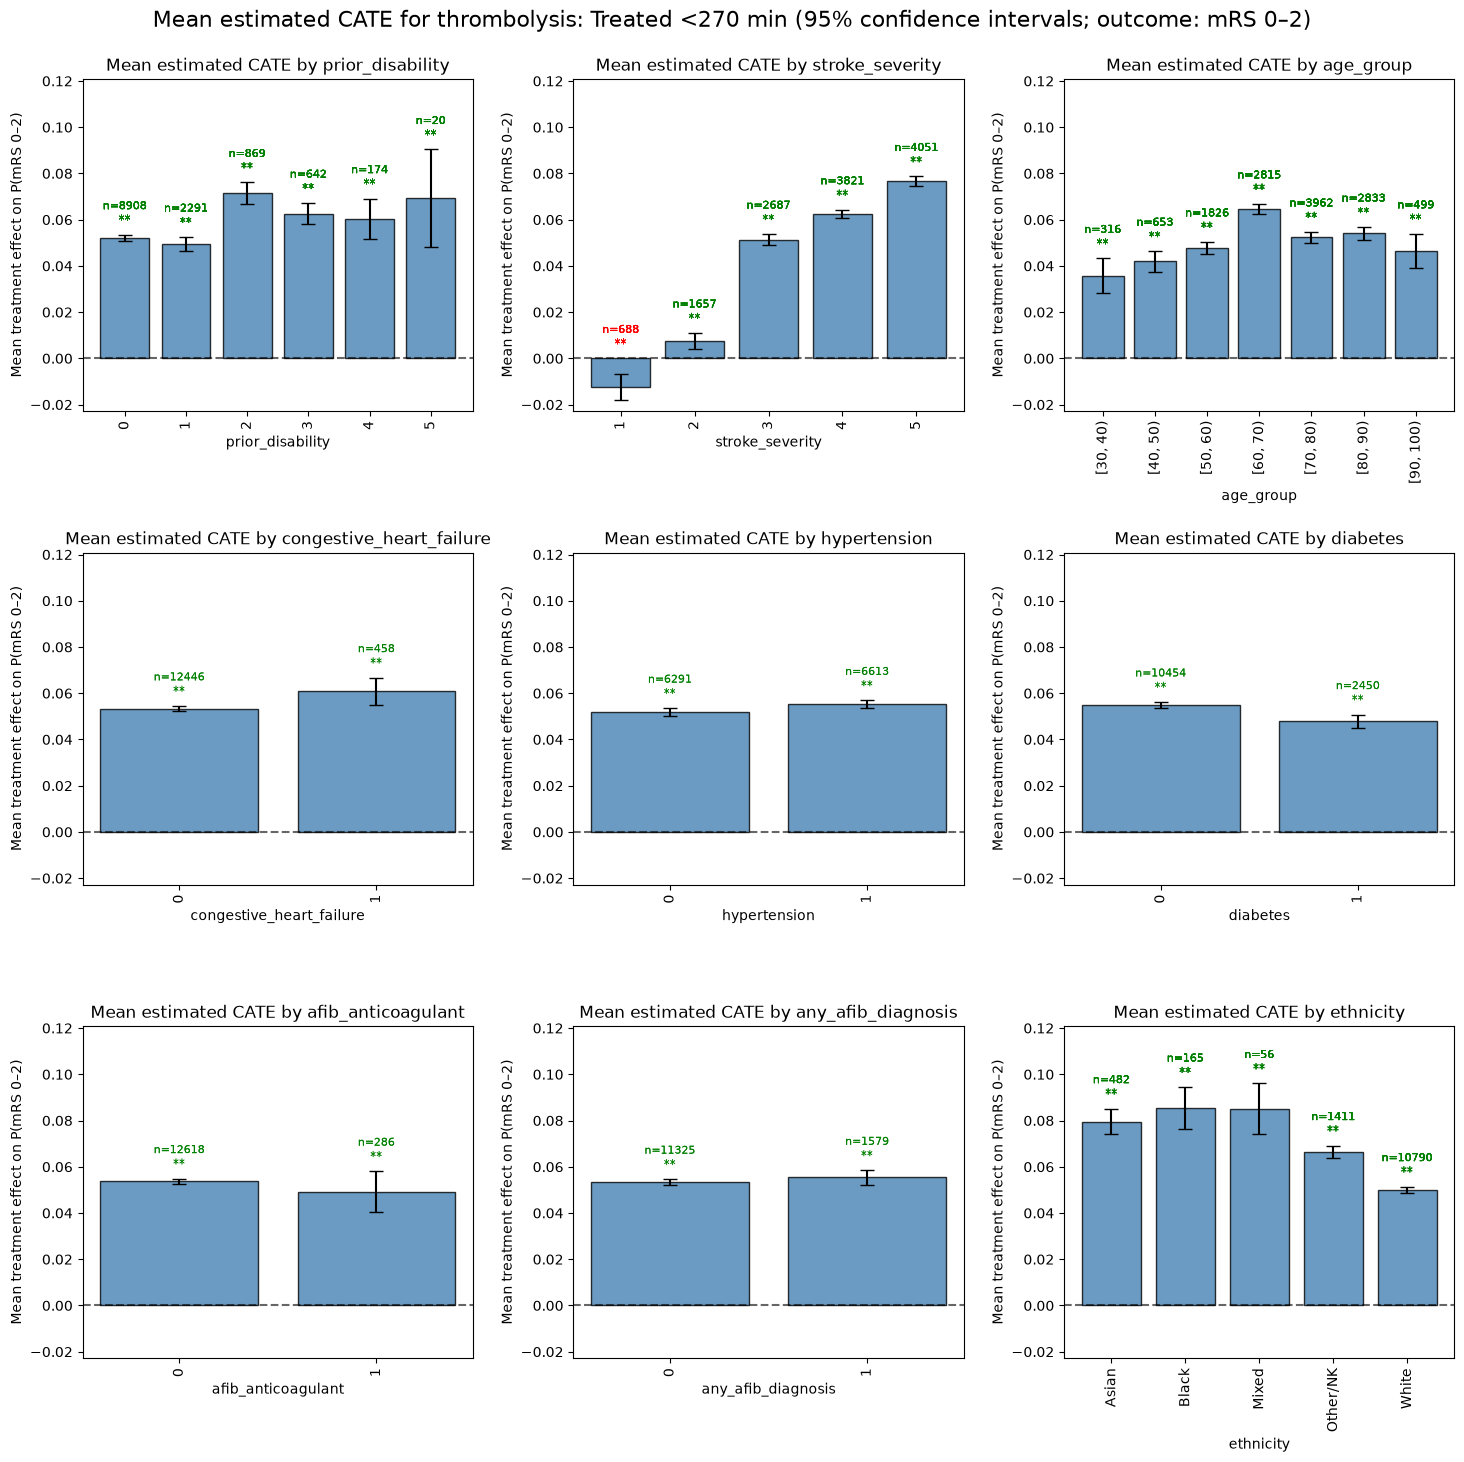

In [23]:
combined_treatment_groups = {
    "Treated <270 min": ["<180 min", "180-270 min"]
}

for group_to_plot, source_groups in combined_treatment_groups.items():
    plot_data = cate_df.loc[
        cate_df["treatment_group"].isin(source_groups)
    ].copy()

    features_to_plot = [
        "prior_disability",
        "stroke_severity",
        "age_group",
        "congestive_heart_failure",
        "hypertension",
        "diabetes",
        "afib_anticoagulant",
        "any_afib_diagnosis",
        "ethnicity",
    ]

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.ravel()

    for i, feature in enumerate(features_to_plot):
        ax = axes[i]
        feature_data = plot_data[[feature, "cate"]].dropna()

        if feature_data.empty:
            ax.set_title(f"No data for {feature}")
            ax.axis("off")
            continue

        order = sorted(
            feature_data[feature].unique(),
            key=lambda value: str(value),
        )

        means = []
        lower_errors = []
        upper_errors = []
        confidence_limits = []

        for level in order:
            values = feature_data.loc[
                feature_data[feature] == level, "cate"
            ].to_numpy()

            mean = values.mean()
            se = values.std(ddof=1) / np.sqrt(len(values)) if len(values) > 1 else 0.0

            ci_lower_95 = mean - 1.96 * se
            ci_upper_95 = mean + 1.96 * se
            ci_lower_99 = mean - 2.576 * se
            ci_upper_99 = mean + 2.576 * se

            means.append(mean)
            lower_errors.append(mean - ci_lower_95)
            upper_errors.append(ci_upper_95 - mean)
            confidence_limits.append(
                (ci_lower_95, ci_upper_95, ci_lower_99, ci_upper_99)
            )

        x_positions = np.arange(len(order))

        ax.bar(
            x_positions,
            means,
            yerr=[lower_errors, upper_errors],
            capsize=5,
            color="steelblue",
            edgecolor="black",
            alpha=0.8,
        )

        for x_pos, (ci_lower_95, ci_upper_95, ci_lower_99, ci_upper_99) in zip(
            x_positions, confidence_limits
        ):
            if ci_lower_99 > 0:
                stars, color = "**", "green"
            elif ci_upper_99 < 0:
                stars, color = "**", "red"
            elif ci_lower_95 > 0:
                stars, color = "*", "green"
            elif ci_upper_95 < 0:
                stars, color = "*", "red"
            else:
                continue

            annotation_y = 0.00 if color == "red" else ci_upper_95
            offset = (0, 0) if color == "red" else (0, 5)

            means = []
            lower_errors = []
            upper_errors = []
            confidence_limits = []
            counts = []

            for level in order:
                values = feature_data.loc[
                    feature_data[feature] == level, "cate"
                ].to_numpy()

                mean = values.mean()
                se = values.std(ddof=1) / np.sqrt(len(values)) if len(values) > 1 else 0.0

                ci_lower_95 = mean - 1.96 * se
                ci_upper_95 = mean + 1.96 * se
                ci_lower_99 = mean - 2.576 * se
                ci_upper_99 = mean + 2.576 * se

                means.append(mean)
                lower_errors.append(mean - ci_lower_95)
                upper_errors.append(ci_upper_95 - mean)
                confidence_limits.append(
                    (ci_lower_95, ci_upper_95, ci_lower_99, ci_upper_99)
                )
                counts.append(len(values))

            for x_pos, (ci_lower_95, ci_upper_95, ci_lower_99, ci_upper_99), count in zip(
                x_positions, confidence_limits, counts
            ):
                if ci_lower_99 > 0:
                    stars, color = "**", "green"
                elif ci_upper_99 < 0:
                    stars, color = "**", "red"
                elif ci_lower_95 > 0:
                    stars, color = "*", "green"
                elif ci_upper_95 < 0:
                    stars, color = "*", "red"
                else:
                    continue

                annotation_y = 0.00 if color == "red" else ci_upper_95
                offset = (0, 6) if color == "red" else (0, 6)

                ax.annotate(
                    f"n={count}\n{stars}",
                    xy=(x_pos, annotation_y),
                    xytext=offset,
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    color=color,
                    fontsize=8,
                )

        ax.axhline(0, color="black", linestyle="--", alpha=0.6)
        ax.set_title(f"Mean estimated CATE by {feature}")
        ax.set_xlabel(feature)
        ax.set_ylabel(f"Mean treatment effect on P(mRS 0–{MRS_TARGET})")
        ax.set_xticks(x_positions)
        ax.set_xticklabels([str(value) for value in order], rotation=90)

    for ax in axes[len(features_to_plot):]:
        ax.axis("off")

    # Make all y axes the same scale
    y_min = min(ax.get_ylim()[0] for ax in axes[:len(features_to_plot)])
    y_max = max(ax.get_ylim()[1] for ax in axes[:len(features_to_plot)]) + 0.02
    for ax in axes[:len(features_to_plot)]:
        ax.set_ylim(y_min, y_max)

    # Convert all float x-tick labels to intergers if they are whole numbers
    for ax in axes[:len(features_to_plot)]:
        x_tick_labels = ax.get_xticklabels()
        new_labels = []
        for label in x_tick_labels:
            try:
                value = float(label.get_text())
                if value.is_integer():
                    new_labels.append(str(int(value)))
                else:
                    new_labels.append(label.get_text())
            except ValueError:
                new_labels.append(label.get_text())
        ax.set_xticklabels(new_labels, rotation=90)

    fig.suptitle(
        f"Mean estimated CATE for thrombolysis: {group_to_plot} "
        f"(95% confidence intervals; outcome: mRS 0–{MRS_TARGET})",
        fontsize=16,
    )

    plt.tight_layout(pad=2)
    plt.savefig(
        f"./output/cate_mean_bar_chart_{MRS_TARGET}_treated_under_270_min.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


In [24]:
# Test whether mean estimated CATE differs across levels of each plotted feature.
anova_results = []

for feature in features_to_plot:
    feature_data = plot_data[[feature, "cate"]].dropna()
    feature_data = feature_data[np.isfinite(feature_data["cate"])]

    if feature_data[feature].nunique() < 2:
        continue

    y = feature_data["cate"].astype(float)
    X = pd.get_dummies(
        feature_data[feature].astype("category"),
        drop_first=True,
        dtype=float,
    )

    # Skip features without enough observations to fit the model.
    if X.empty or len(y) <= X.shape[1] + 1:
        continue

    model = sm.OLS(y, sm.add_constant(X, has_constant="add")).fit()

    anova_results.append({
        "feature": feature,
        "f_statistic": model.fvalue,
        "p_value": model.f_pvalue,
        "n": len(y),
        "n_levels": feature_data[feature].nunique(),
    })

anova_results_df = pd.DataFrame(anova_results)
anova_results_df.round(3)



,feature,f_statistic,p_value,n,n_levels
0,prior_disability,17.096,0.000,12904,6
1,stroke_severity,554.598,0.000,12904,5
2,age_group,22.032,0.000,12904,7
3,congestive_heart_failure,5.387,0.020,12904,2
4,hypertension,7.175,0.007,12904,2
5,diabetes,20.895,0.000,12904,2
6,afib_anticoagulant,1.188,0.276,12904,2
7,any_afib_diagnosis,1.184,0.276,12904,2
8,ethnicity,48.676,0.000,12904,5
